# Chapter 4 - Machine Coordinates in SciBmad

In the previous chapters, we mostly treated a lattice as a one-dimensional sequence indexed by the path length `s`. In this chapter, we ask a different question: how is that sequence embedded in physical space?

The goal is to understand three related ideas:

1. the difference between global, local/reference, and element-body coordinates;
2. the difference between straight, bend, and patch geometry;
3. how to represent element misalignments and patch elements in SciBmad.

This chapter intentionally compares the original Bmad variable names with the SciBmad names, because the coordinate conventions are the main topic here. Later chapters will return to a more SciBmad-native style.


## 4.1 Coordinate systems

The original tutorial distinguishes three coordinate systems.

### Global coordinates

The global or floor coordinate system is written as `(X, Y, Z)`. It is fixed to the building. Usually, `Y` points vertically upward, while `(X, Z)` is the horizontal floor plane.

### Local/reference coordinates

The local coordinate system is written as `(x, y, z)`. It moves along the reference trajectory. At each position `s`, the origin lies on the reference orbit, the local `z` axis is tangent to the reference orbit, and `x` and `y` are transverse directions.

### Element body coordinates

The element body coordinates are attached to the physical magnet or element. If an element is perfectly aligned, the body frame coincides with the local reference frame. If the element is misaligned, the body frame is shifted or rotated relative to the local frame.

For a point on the reference orbit, the local frame can be described relative to the global frame by six quantities:

```text
X, Y, Z, θ, φ, ψ
```

where `θ` is the azimuth angle in the horizontal plane, `φ` is the elevation angle, and `ψ` is the roll angle. These angles play the role of yaw/pitch/roll-like orientation variables for the local frame.

In this tutorial, we stay in the horizontal plane and take

```text
Y = 0, φ = 0, ψ = 0.
```

So for visualization we only keep track of

```text
X, Z, θ.
```


## 4.2 Geometry types

There are three geometry types that matter for this chapter.

### Straight geometry

Drifts and quadrupoles are straight elements. Their reference trajectory is a straight line, so the local frame direction does not change through the element.

### Bend geometry

Dipole bend elements make the reference trajectory curve. The local frame rotates along the reference trajectory.

### Patch geometry

A patch element shifts and rotates the downstream reference frame. It is not a magnet. It is a field-free coordinate transformation.

This distinction is important:

```text
misalignment  -> changes the physical element body frame
patch         -> changes the downstream reference frame itself
```


## 4.3 Bmad-to-SciBmad naming map

Bmad writes many of these quantities directly as element attributes. SciBmad organizes them into parameter groups.

For element misalignments, SciBmad uses `AlignmentParams`. For patch elements, SciBmad uses `PatchParams`.

In this tutorial we use the following working map. We assume positive signs under this map.

| Bmad name | SciBmad name for misalignment | SciBmad name for patch | Meaning |
|---|---:|---:|---|
| `x_offset` | `x_offset` | `dx` | shift in local `x` |
| `y_offset` | `y_offset` | `dy` | shift in local `y` |
| `z_offset` | `z_offset` | `dz` | shift in local `z` |
| `x_pitch` | `y_rot` | `dy_rot` | rotate `+z` toward `+x` |
| `y_pitch` | `x_rot` | `dx_rot` | rotate `+z` toward `+y` |
| `tilt` | `tilt` | `dz_rot` | rotate around local `z` |

The most important subtlety is that Bmad's `x_pitch` is named by the direction toward which the `z` axis moves, while SciBmad's `x_rot` and `y_rot` are named by the rotation axis. Therefore Bmad `x_pitch` corresponds to a rotation about the local `y` axis, so we represent it as `y_rot` or `dy_rot` in this tutorial.


## 4.4 SciBmad setup

The following cell imports SciBmad. If you are working inside the same environment as the previous chapters, this should be enough.


In [1]:
using SciBmad

## 4.5 Example 1: a misaligned quadrupole

The Bmad example in the original tutorial is:

```bmad
beginning[beta_a] = 10.
beginning[beta_b] = 10.
beginning[e_tot] = 10e6
parameter[geometry] = open

q: quadrupole, L = 1, x_offset = 0.1, x_pitch = 0.04

lat: line = (q)
use, lat
```

This element is a straight element. Its nominal reference frame still goes straight from `s = 0` to `s = 1`. The misalignment changes the physical element body frame, not the downstream reference frame.

Using the sign convention of this tutorial, Bmad `x_pitch = 0.04` is represented as SciBmad `y_rot = 0.04`.


In [2]:
q = Quadrupole(name = "Q", L = 1.0)

q.AlignmentParams = AlignmentParams(
    x_offset = 0.1,
    y_rot    = 0.04,
)

lat_misaligned = Beamline(
    [q];
    species_ref = Species("electron"),
    E_ref = 10e6,
)

lat_misaligned


Beamline:
 species_ref = electron
 E_ref = 1.0e7

  Index   Name   Kind         s [m] 
  1       Q      Quadrupole   0


The important point is:

```text
A misalignment changes the physical element body frame,
but it does not redefine the downstream reference trajectory.
```

Therefore elements downstream of a misaligned quadrupole are not automatically shifted or rotated by the quadrupole's misalignment.


## 4.6 Example 2: a patch element

The patch example in the original tutorial is:

```bmad
beginning[beta_a] = 10.
beginning[beta_b] = 10.
beginning[e_tot] = 10e6
parameter[geometry] = open

b: sbend, L = 0.5, g = 1
p: patch, z_offset = 1, x_pitch = pi/4
q: quadrupole, L = 0.6, k1 = 0.23

lat: line = (b, p, q)
use, lat
```

In SciBmad, the bend curvature is represented with `g_ref`. The patch is represented with `PatchParams`. Under our sign convention, Bmad `x_pitch = π/4` becomes SciBmad `dy_rot = π/4`.

The quadrupole strength `k1 = 0.23` is included as a comment below because the exact field-strength parameter convention may depend on the version of your SciBmad setup. The geometry of this chapter only depends on the quadrupole length and placement.


In [3]:
b = SBend(name = "B", L = 0.5, g_ref = 1.0)

p = Patch(name = "P")
p.PatchParams = PatchParams(
    dz     = 1.0,
    dy_rot = π/4,
)

q = Quadrupole(name = "Q", L = 0.6)

# If your SciBmad setup uses a direct normalized quadrupole strength property,
# you can set it here using the convention used in the previous chapters, for example:
# q.Kn1 = 0.23
# or
# q.K1 = 0.23

lat_patch = Beamline(
    [b, p, q];
    species_ref = Species("electron"),
    E_ref = 10e6,
)

lat_patch


Beamline:
 species_ref = electron
 E_ref = 1.0e7

  Index   Name   Kind         s [m] 
  1       B      SBend        0
  2       P      Patch        0.5
  3       Q      Quadrupole   0.5


The patch does something fundamentally different from a misalignment:

```text
A patch changes the reference frame itself.
```

Therefore all downstream elements are placed relative to the new reference frame.


## 4.7 A simple floor-coordinate visualizer

Tao can directly print floor coordinates using commands like

```bmad
show lat -floor
show ele q -floor
```

SciBmad does not use that Tao command interface. For this tutorial, we build a small visualization helper for the horizontal plane. This helper is pedagogical: it is only meant to illustrate how straight elements, bends, and patches move the reference frame.

We track the floor-frame variables

```text
X, Z, θ.
```

Here `θ` is the angle of the local `z` axis relative to the global `Z` direction.


In [4]:
using Printf

struct FloorFrame
    X::Float64
    Z::Float64
    θ::Float64
end

function propagate_straight(f::FloorFrame, L)
    X_new = f.X + L * sin(f.θ)
    Z_new = f.Z + L * cos(f.θ)
    return FloorFrame(X_new, Z_new, f.θ)
end

function propagate_bend(f::FloorFrame, L, g)
    if abs(g) < 1e-14
        return propagate_straight(f, L)
    end

    # Convention chosen to match the original Chapter 4 example:
    # positive g gives θ -> θ - gL.
    Δθ = -g * L
    θ0 = f.θ
    θ1 = θ0 + Δθ

    X_new = f.X + (cos(θ1) - cos(θ0)) / g
    Z_new = f.Z + (sin(θ0) - sin(θ1)) / g

    return FloorFrame(X_new, Z_new, θ1)
end

function propagate_patch(f::FloorFrame; dx = 0.0, dz = 0.0, dy_rot = 0.0)
    # Translate by dx and dz in the old local frame.
    X_new = f.X + dz * sin(f.θ) + dx * cos(f.θ)
    Z_new = f.Z + dz * cos(f.θ) - dx * sin(f.θ)

    # Working sign convention:
    # Bmad x_pitch -> SciBmad dy_rot with positive sign.
    θ_new = f.θ + dy_rot

    return FloorFrame(X_new, Z_new, θ_new)
end

function print_frame(name, f::FloorFrame)
    @printf("%-10s  X = %+9.5f   Z = %+9.5f   θ = %+9.5f\n",
            name, f.X, f.Z, f.θ)
end


print_frame (generic function with 1 method)

Now reproduce the numerical geometry of the original patch example:

```text
b: sbend, L = 0.5, g = 1
p: patch, z_offset = 1, x_pitch = π/4
q: quadrupole, L = 0.6
```


In [5]:
f0 = FloorFrame(0.0, 0.0, 0.0)

fB = propagate_bend(f0, 0.5, 1.0)
fP = propagate_patch(fB; dz = 1.0, dy_rot = π/4)
fQ = propagate_straight(fP, 0.6)

print_frame("BEGIN", f0)
print_frame("B", fB)
print_frame("P", fP)
print_frame("Q", fQ)


BEGIN       X =  +0.00000   Z =  +0.00000   θ =  +0.00000
B           X =  -0.12242   Z =  +0.47943   θ =  -0.50000
P           X =  -0.60184   Z =  +1.35701   θ =  +0.28540
Q           X =  -0.43292   Z =  +1.93274   θ =  +0.28540


The output should be approximately:

```text
BEGIN       X =  +0.00000   Z =  +0.00000   θ =  +0.00000
B           X =  -0.12242   Z =  +0.47943   θ =  -0.50000
P           X =  -0.60184   Z =  +1.35701   θ =  +0.28540
Q           X =  -0.43288   Z =  +1.93275   θ =  +0.28540
```

This reproduces the structure of the original example:

1. the bend rotates the reference frame;
2. the patch shifts and rotates the downstream frame;
3. the quadrupole is placed along the new downstream frame.


## 4.8 Plotting the reference frames

The following plotting cell is optional. It uses `Plots.jl` only to visualize the points computed by the helper above. If `Plots.jl` is not installed, you can skip this cell.


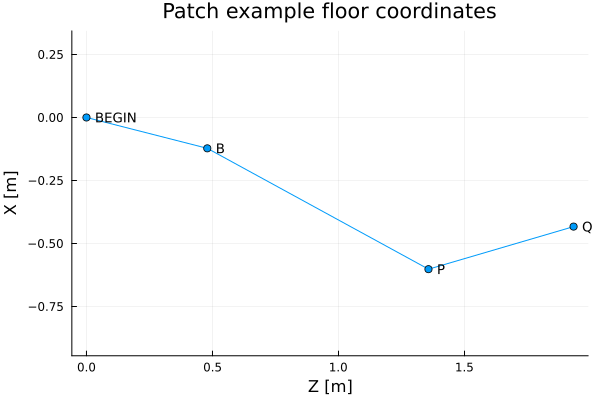

In [6]:
using Plots

Xs = [f0.X, fB.X, fP.X, fQ.X]
Zs = [f0.Z, fB.Z, fP.Z, fQ.Z]
labels = ["BEGIN", "B", "P", "Q"]

plot(Zs, Xs;
    marker = :circle,
    xlabel = "Z [m]",
    ylabel = "X [m]",
    aspect_ratio = :equal,
    legend = false,
    title = "Patch example floor coordinates",
)

for (Z, X, label) in zip(Zs, Xs, labels)
    annotate!(Z, X, text("  " * label, 9, :left))
end

plot!()


## 4.9 Misalignment versus patch

It is useful to contrast the two transformations.

A misaligned quadrupole can be written as:

```julia
q = Quadrupole(name = "Q", L = 1.0)
q.AlignmentParams = AlignmentParams(
    x_offset = 0.1,
    y_rot    = 0.04,
)
```

This means:

```text
reference frame: unchanged
element body frame: shifted and rotated
downstream elements: unchanged
```

A patch can be written as:

```julia
p = Patch(name = "P")
p.PatchParams = PatchParams(
    dz     = 1.0,
    dy_rot = π/4,
)
```

This means:

```text
reference frame: shifted and rotated
element body frame: not the main issue
downstream elements: placed in the new reference frame
```

The parameters look similar, but their meanings are different.


## 4.10 Summary

In this chapter, we moved from a purely one-dimensional view of a lattice to a geometric view of the accelerator embedded in space.

The main ideas are:

1. The global frame is fixed to the building.
2. The local/reference frame moves along the design orbit.
3. The element body frame is attached to the physical element.
4. Straight elements keep the reference direction fixed.
5. Bend elements rotate the reference frame along a curved path.
6. Misalignments move the physical element relative to the reference frame.
7. Patch elements redefine the downstream reference frame.

In SciBmad, the most important parameter groups for this chapter are:

```julia
AlignmentParams(...)
PatchParams(...)
BendParams(...)
```

Use `AlignmentParams` for physical element misalignments and `PatchParams` for reference-coordinate jumps.


## Exercises

### Exercise 1: Change the quadrupole misalignment

Start from:

```julia
q = Quadrupole(name = "Q", L = 1.0)
q.AlignmentParams = AlignmentParams(
    x_offset = 0.1,
    y_rot    = 0.04,
)
```

Change `x_offset` to `0.2`. Does this change the downstream reference frame? Explain why or why not.

### Exercise 2: Change the patch rotation

Start from:

```julia
f0 = FloorFrame(0.0, 0.0, 0.0)
fB = propagate_bend(f0, 0.5, 1.0)
fP = propagate_patch(fB; dz = 1.0, dy_rot = π/4)
fQ = propagate_straight(fP, 0.6)
```

Change `dy_rot = π/4` to `dy_rot = π/6`. How does the final position of `Q` change?

### Exercise 3: Remove the patch

Construct the same sequence without the patch:

```julia
f0 = FloorFrame(0.0, 0.0, 0.0)
fB = propagate_bend(f0, 0.5, 1.0)
fQ = propagate_straight(fB, 0.6)

print_frame("B", fB)
print_frame("Q", fQ)
```

Compare this result with the case containing the patch. Explain why the final quadrupole location is different.

### Exercise 4: Add a horizontal patch offset

Use:

```julia
fP = propagate_patch(fB; dx = 0.2, dz = 1.0, dy_rot = π/4)
```

How does `dx` differ from `dz` geometrically? Which direction is each offset applied in?
